# Data Documentation

Based on the documentation provided:

**Files dataXXX.csv:**
*   **Column 1:** Relative time (s)
*   **Columns 2-7:** Setpoints of the joints (segments 0-5)
*   **Columns 8-13:** Actual motor axis positions (segments 0-5)

**Files trackXXX.csv:**
*   **Column 1:** Absolute time
*   **Column 2:** Frame number
*   **Column 3:** Number of points detected
*   **Columns 4+:** Detected points (id, x, y)


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# Define data paths - relative to this notebook
data_dir = '../experimental_data'
data_files = [
    os.path.join(data_dir, 'data1.csv'),
    os.path.join(data_dir, 'data2.csv'),
    os.path.join(data_dir, 'data3.csv')
]

def load_data(filepath):
    # Load CSV. No header?
    # Based on chat: time, 6 setpoints, 6 positions
    # 13 columns
    try:
        # Check if file exists
        if not os.path.exists(filepath):
            print(f"Error: {filepath} not found.")
            return None

        df = pd.read_csv(filepath, header=None)
        if df.shape[1] != 13:
            print(f"Warning: {filepath} has {df.shape[1]} columns instead of 13")

        column_names = ['time'] + [f'setpoint_{i}' for i in range(6)] + [f'pos_{i}' for i in range(6)]
        df.columns = column_names[:df.shape[1]]
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

dfs = {os.path.basename(f): load_data(f) for f in data_files}

for name, df in dfs.items():
    if df is not None:
        print(f"{name}: {len(df)} rows")
        print(df.head())

data1.csv: 1024 rows
    time  setpoint_0  setpoint_1  setpoint_2  setpoint_3  setpoint_4  \
0  0.007         0.0         0.0         0.0         0.7         0.7   
1  0.015         0.0         0.7         0.7         0.7         0.7   
2  0.022         0.0         0.7         0.7         1.3         1.3   
3  0.029         0.0         1.3         1.3         1.3         1.3   
4  0.036         0.0         1.3         1.3         1.3         2.0   

   setpoint_5  pos_0  pos_1  pos_2  pos_3  pos_4  pos_5  
0         0.7    0.0    0.0    0.0    0.0    0.0    0.0  
1         0.7    0.0    0.0    0.0    0.0    0.0    0.0  
2         1.3    0.0    0.0    0.0    0.0    0.0    0.0  
3         1.3    0.0    0.0    0.0    0.0    0.0    0.0  
4         2.0    0.0    0.0    0.0    0.7    0.7    0.0  
data2.csv: 1024 rows
    time  setpoint_0  setpoint_1  setpoint_2  setpoint_3  setpoint_4  \
0  0.007         0.0         0.0         0.0         0.0         0.7   
1  0.015         0.0         0.7 

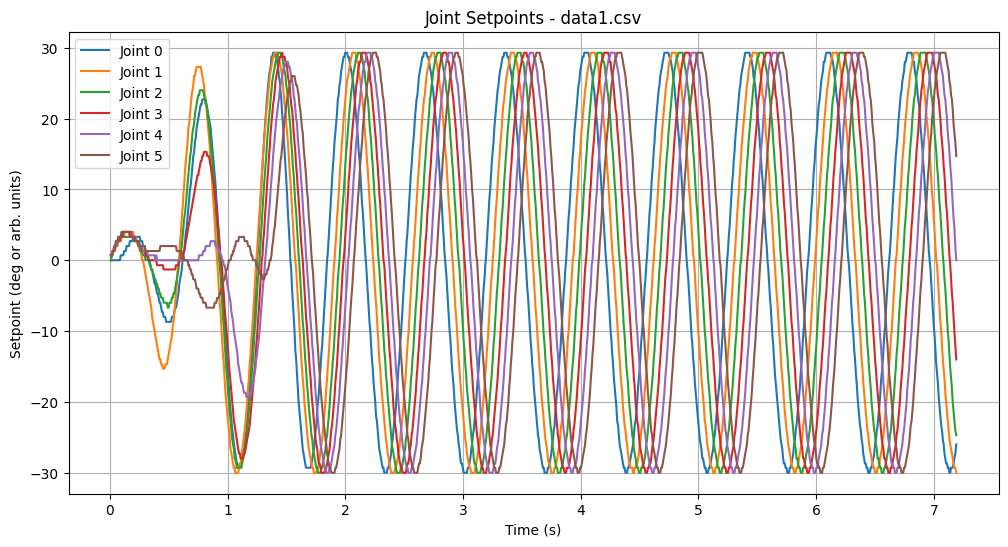

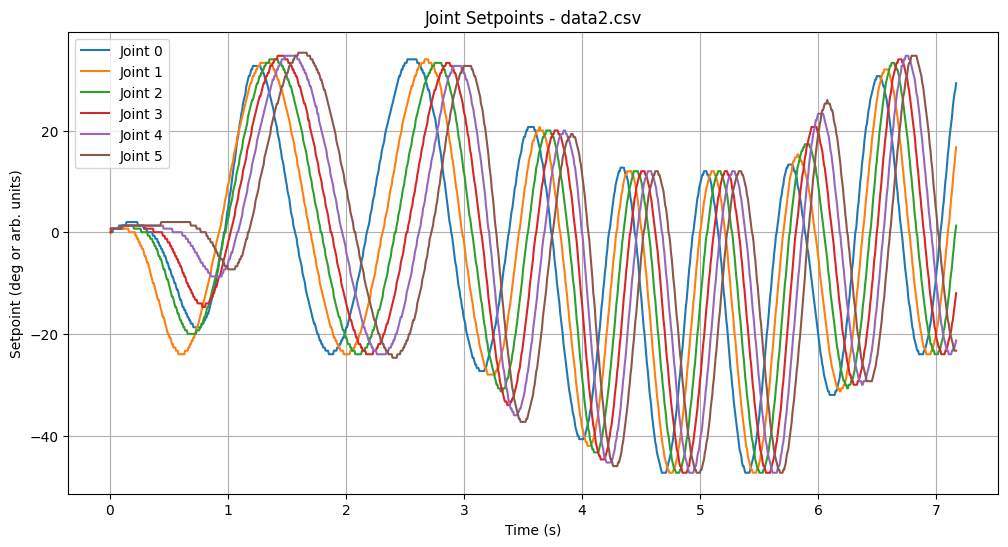

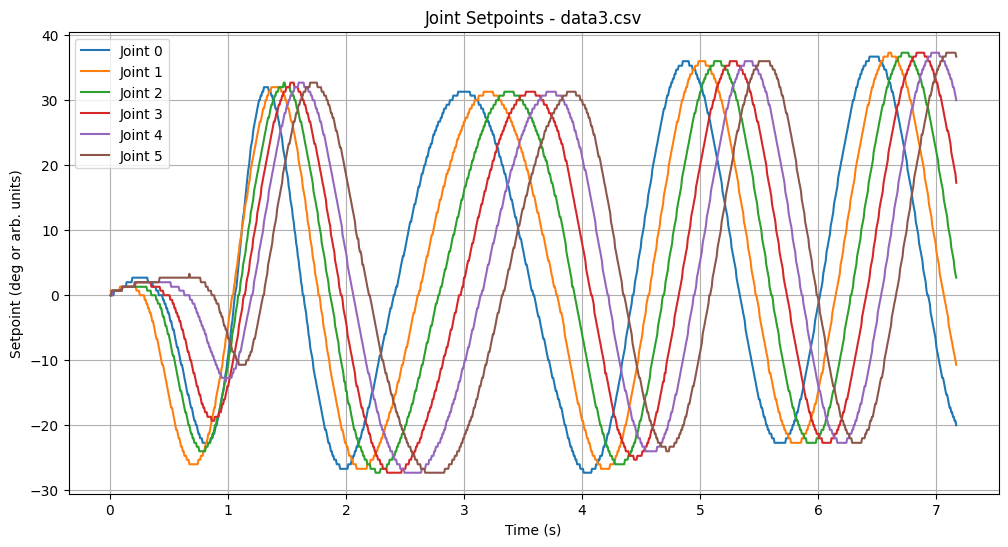

In [76]:
# Plot Joint Setpoints
for name, df in dfs.items():
    if df is None: continue

    plt.figure(figsize=(12, 6))
    for i in range(6):
        plt.plot(df['time'], df[f'setpoint_{i}'], label=f'Joint {i}')

    plt.title(f'Joint Setpoints - {name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Setpoint (deg or arb. units)')
    plt.legend()
    plt.grid(True)
    plt.show()


In [77]:
# Process Tracking Data
track_files = [
    os.path.join(data_dir, 'track1.csv'),
    os.path.join(data_dir, 'track2.csv'),
    os.path.join(data_dir, 'track3.csv')
]

def load_track_data(filepath):
    if not os.path.exists(filepath):
        print(f"Error: {filepath} not found")
        return None

    data = []

    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 3:
                continue

            try:
                t = float(parts[0])
                frame = int(parts[1])
                count = int(parts[2])

                row = {'time': t, 'frame': frame}

                for i in range(count):
                    idx_start = 3 + i*3
                    if idx_start + 2 < len(parts):
                        try:
                            id_val = int(parts[idx_start])
                            x = float(parts[idx_start+1])
                            y = float(parts[idx_start+2])

                            row[f'x_{id_val}'] = x
                            row[f'y_{id_val}'] = y
                        except ValueError:
                            continue

                data.append(row)
            except ValueError:
                continue

    df = pd.DataFrame(data)

    # Sort columns: time, frame, then x_1, y_1, x_2, y_2...
    if not df.empty:
        non_coord_cols = ['time', 'frame']
        coord_cols = [c for c in df.columns if c not in non_coord_cols]

        # Sort coordinate columns by ID and then type (x or y)
        def sort_key(col_name):
            prefix, id_str = col_name.split('_')
            return int(id_str), prefix # x comes before y in 'x' vs 'y' string?? No 'x' > 'y' in ascii? 'x' is 120, 'y' is 121. So x before y.

        coord_cols.sort(key=lambda x: (int(x.split('_')[1]), x.split('_')[0]))

        df = df[non_coord_cols + coord_cols]

    return df

track_dfs = {os.path.basename(f): load_track_data(f) for f in track_files}

for name, df in track_dfs.items():
    if df is not None:
        print(f"{name}: {len(df)} frames")
        # Print detected IDs
        cols = [c for c in df.columns if c.startswith('x_')]
        ids = sorted([int(c.split('_')[1]) for c in cols])
        print(f"  Detected IDs: {ids}")


track1.csv: 570 frames
  Detected IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]
track2.csv: 775 frames
  Detected IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 101, 102, 103, 104]
track3.csv: 333 frames
  Detected IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113]


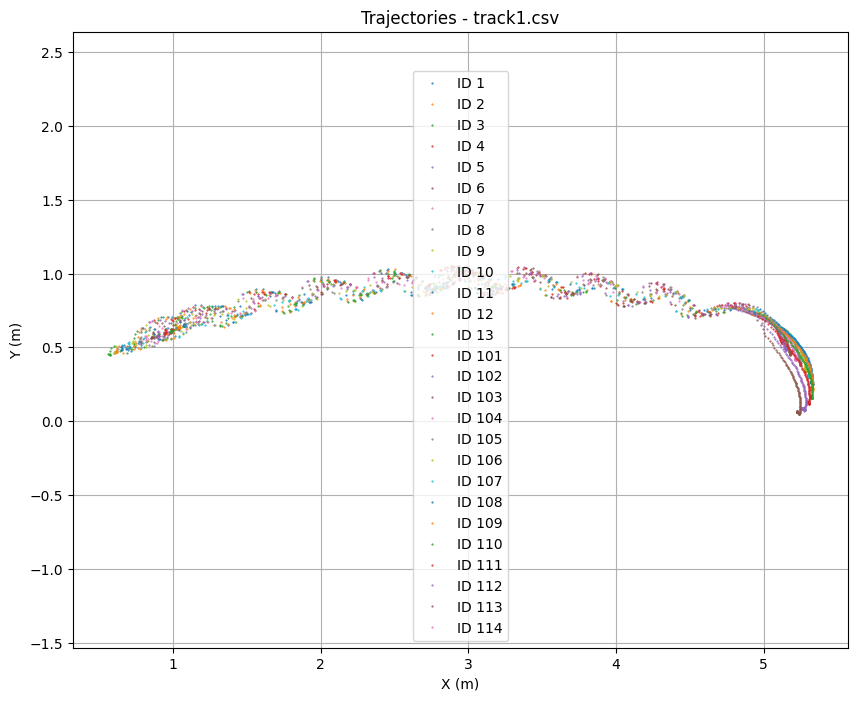

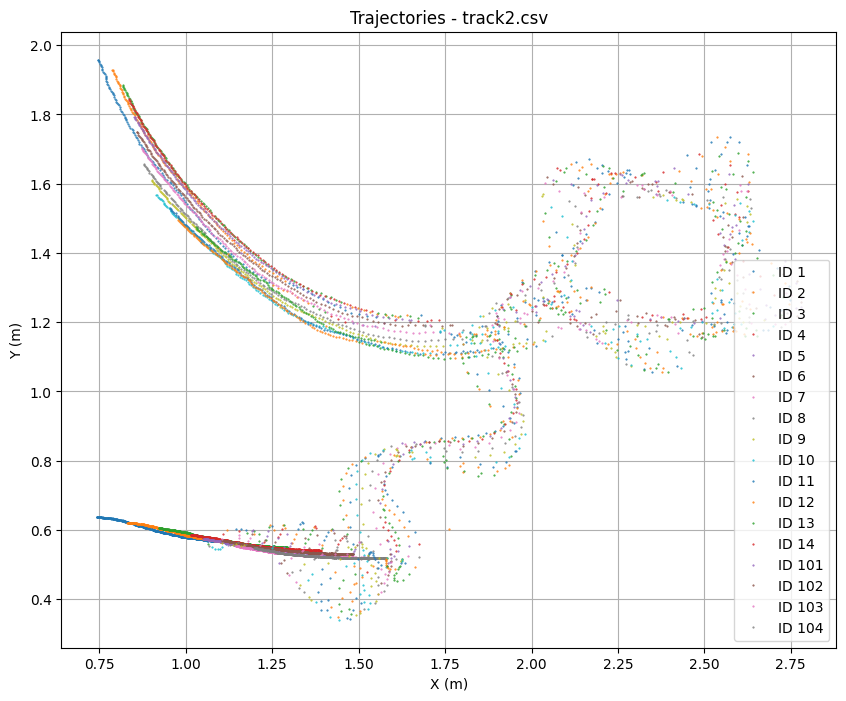

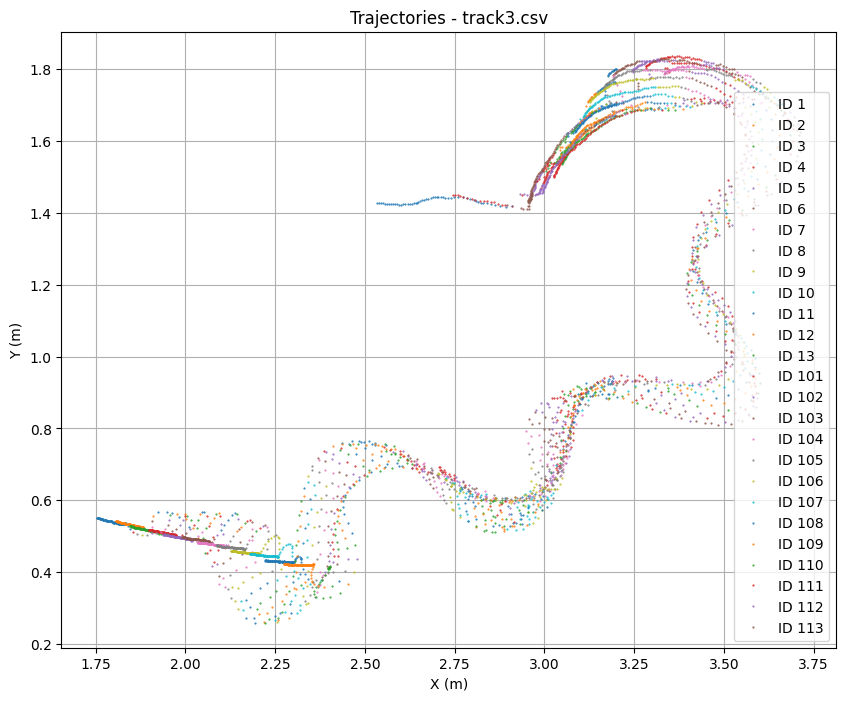

In [78]:
# Plot Trajectories
for name, df in track_dfs.items():
    if df is None or df.empty: continue

    plt.figure(figsize=(10, 8))

    # Get all IDs
    cols = [c for c in df.columns if c.startswith('x_')]
    ids = sorted([int(c.split('_')[1]) for c in cols])

    for id_val in ids:
        x_col = f'x_{id_val}'
        y_col = f'y_{id_val}'

        # Plot only points where both x and y are not NaN
        mask = df[x_col].notna() & df[y_col].notna()
        plt.plot(df.loc[mask, x_col], df.loc[mask, y_col], '.', markersize=1, label=f'ID {id_val}')

    plt.title(f'Trajectories - {name}')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.axis('equal')
    plt.legend()
    plt.grid(True)
    plt.show()


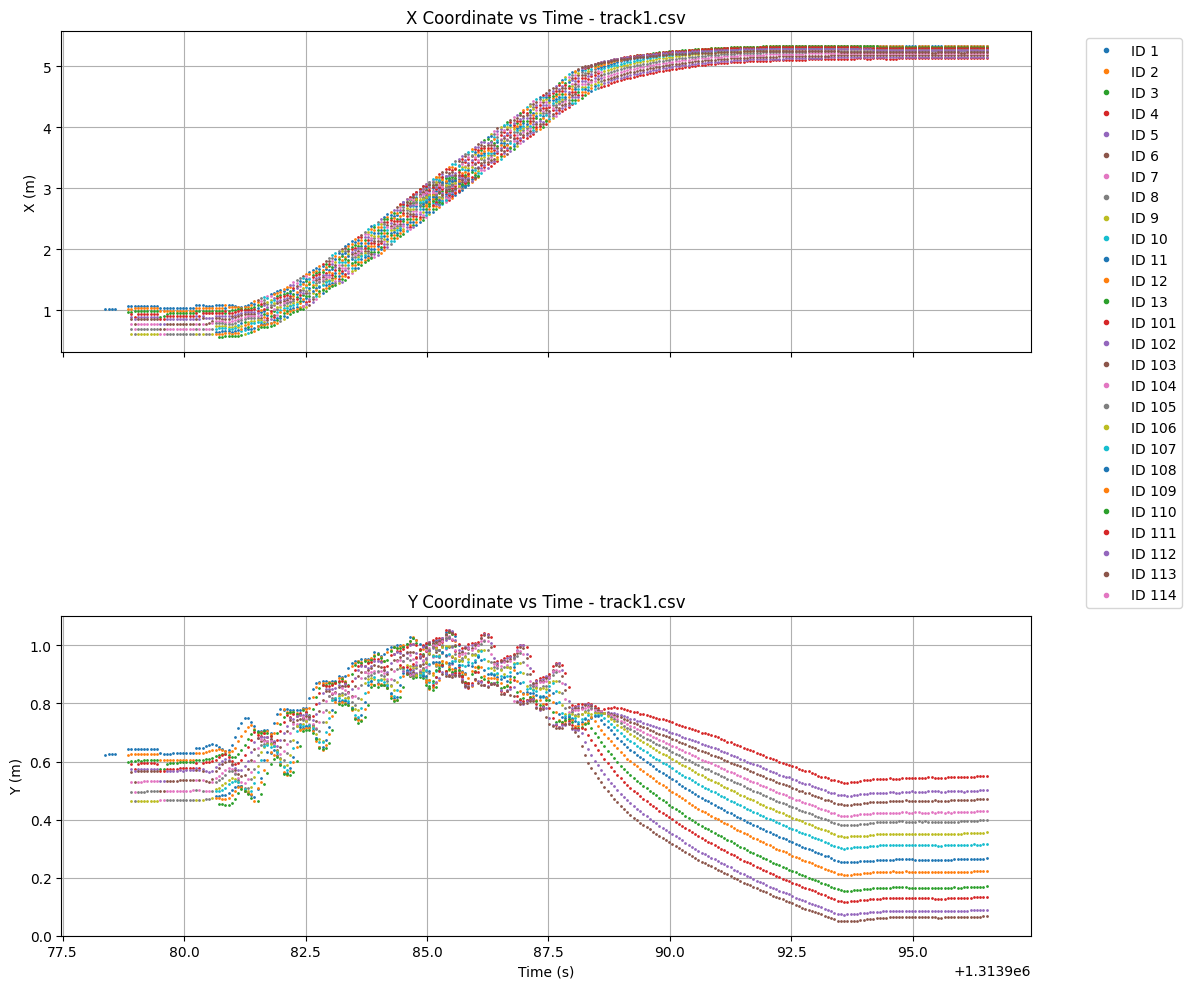

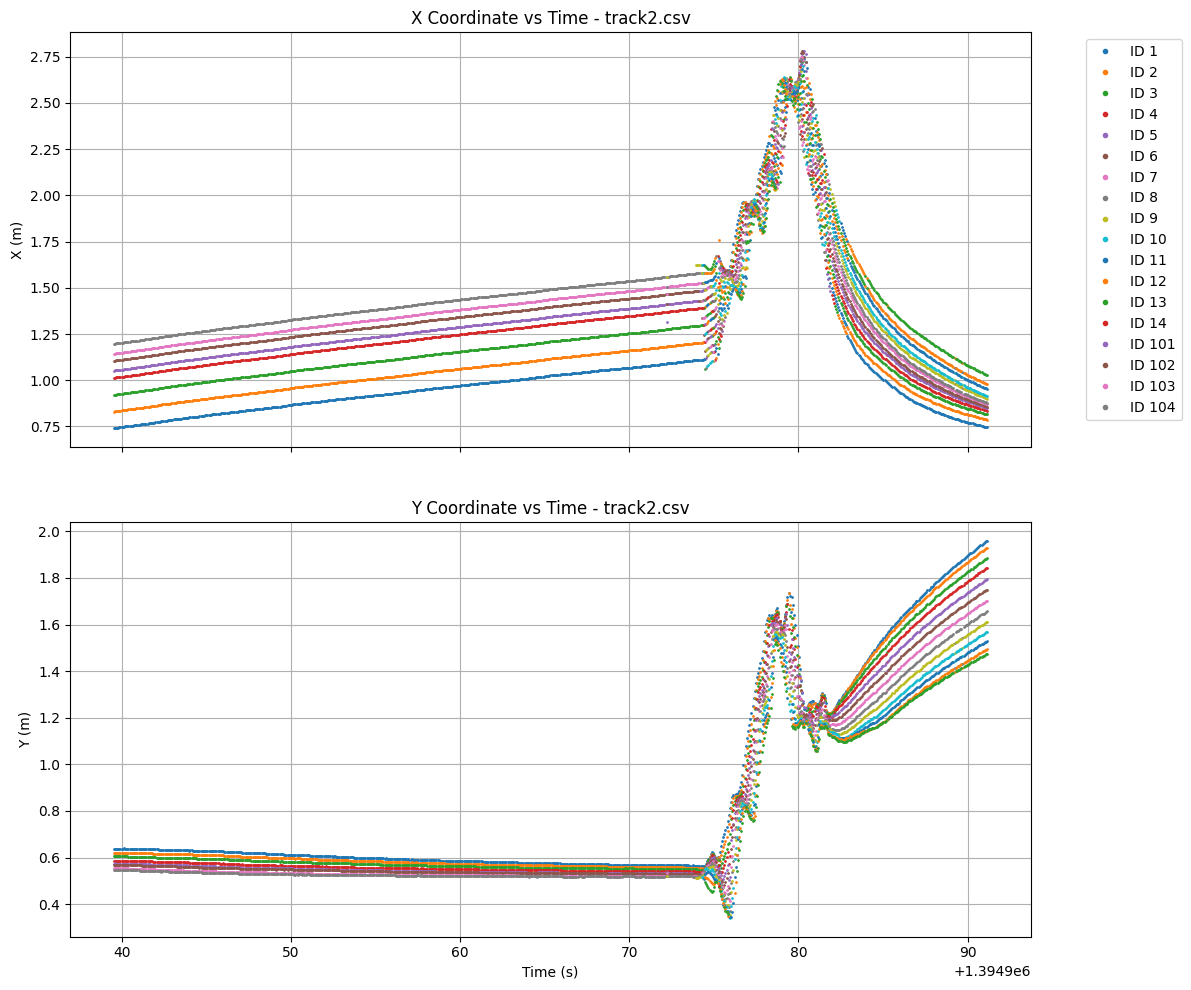

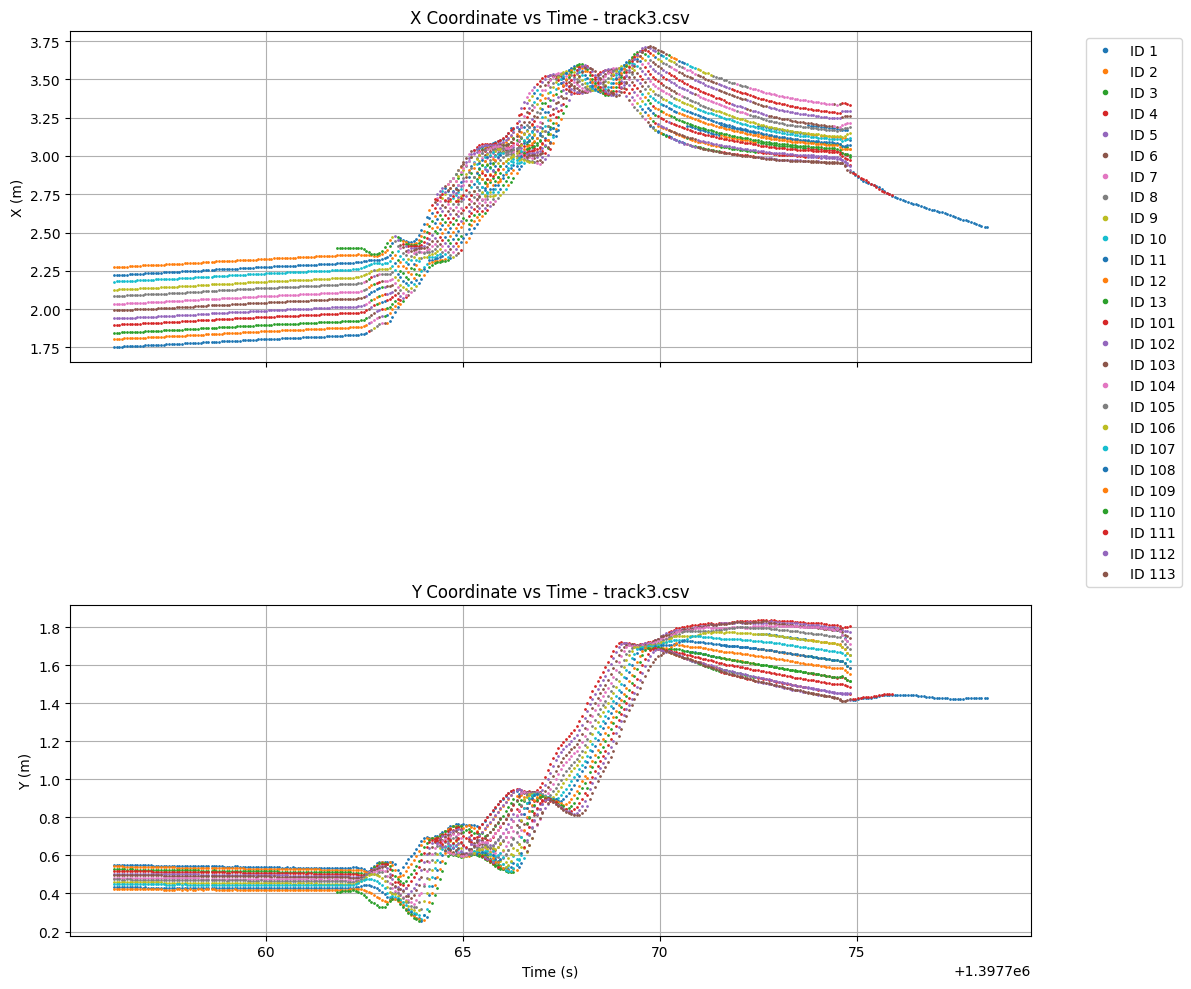

In [79]:
# Plot X and Y coordinates over time to inspect tracking quality
for name, df in track_dfs.items():
    if df is None or df.empty: continue

    # Get all IDs
    cols = [c for c in df.columns if c.startswith('x_')]
    ids = sorted([int(c.split('_')[1]) for c in cols])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    for id_val in ids:
        x_col = f'x_{id_val}'
        y_col = f'y_{id_val}'

        # Plot raw points
        ax1.plot(df['time'], df[x_col], '.', markersize=2, label=f'ID {id_val}')
        ax2.plot(df['time'], df[y_col], '.', markersize=2, label=f'ID {id_val}')

    ax1.set_title(f'X Coordinate vs Time - {name}')
    ax1.set_ylabel('X (m)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3)
    ax1.grid(True)

    ax2.set_title(f'Y Coordinate vs Time - {name}')
    ax2.set_ylabel('Y (m)')
    ax2.set_xlabel('Time (s)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Corrected Track Reconstruction

**Problems with raw IDs:**
1. IDs 1-13 = Camera 1, IDs 101+ = Camera 2. Both cameras track the **same 13 physical LEDs**.
2. IDs are **NOT stable** across frames — the camera reassigns them arbitrarily.
3. In overlap regions, both cameras see the same LEDs → duplicates ~2cm apart.

**Approach:**
1. Extract all (x, y) points per frame, ignoring IDs
2. Deduplicate overlapping camera detections (merge points < 2cm apart)
3. Order remaining ~13 points spatially along the body (nearest-neighbor chain walk)
4. Track the 13 physical LEDs frame-to-frame using the Hungarian algorithm
5. Interpolate gaps where LEDs were lost

In [80]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

def extract_points_per_frame(df):
    """Extract list of (x, y) points per frame, ignoring IDs entirely."""
    x_cols = [c for c in df.columns if c.startswith('x_')]

    frames = []
    for _, row in df.iterrows():
        pts = []
        for xc in x_cols:
            id_str = xc.split('_')[1]
            yc = f'y_{id_str}'
            if yc in df.columns:
                xv, yv = row[xc], row[yc]
                if pd.notna(xv) and pd.notna(yv):
                    pts.append([xv, yv])
        frames.append(np.array(pts) if pts else np.empty((0, 2)))
    return frames

def deduplicate_cameras(points, merge_dist=0.025):
    """Merge points from overlapping cameras.
    Camera duplicates ~5mm apart; LED spacing ~4-5cm.
    merge_dist=2.5cm safely merges duplicates without merging different LEDs."""
    if len(points) <= 1:
        return points

    pts = np.array(points)
    merged = []
    used = set()

    for i in range(len(pts)):
        if i in used:
            continue
        cluster = [pts[i]]
        for j in range(i + 1, len(pts)):
            if j in used:
                continue
            if np.linalg.norm(pts[i] - pts[j]) < merge_dist:
                cluster.append(pts[j])
                used.add(j)
        used.add(i)
        merged.append(np.mean(cluster, axis=0))

    return np.array(merged)

def chain_order_points(points):
    """Order points along the body by nearest-neighbor chain walk.
    Start from the point with smallest x (one end of the body)."""
    if len(points) <= 1:
        return points

    pts = np.array(points)
    start = np.argmin(pts[:, 0])

    ordered = [start]
    remaining = set(range(len(pts))) - {start}

    while remaining:
        curr = ordered[-1]
        dists = {j: np.linalg.norm(pts[curr] - pts[j]) for j in remaining}
        nearest = min(dists, key=dists.get)
        ordered.append(nearest)
        remaining.remove(nearest)

    return pts[ordered]

def reconstruct_tracks_v2(df, num_leds=13, merge_dist=0.025):
    """
    Pipeline: extract → deduplicate → chain-order ONLY reference →
    Hungarian match with PER-TRACK dynamic threshold.
    Interpolation limited to short gaps (max 3 frames) to avoid fake data.
    """
    raw_frames = extract_points_per_frame(df)
    times = df['time'].values
    frame_nums = df['frame'].values
    n_frames = len(raw_frames)

    # Deduplicate each frame (no chain ordering except reference)
    processed_frames = []
    for pts in raw_frames:
        if len(pts) == 0:
            processed_frames.append(np.empty((0, 2)))
            continue
        deduped = deduplicate_cameras(pts, merge_dist=merge_dist)
        processed_frames.append(deduped)

    counts = [len(p) for p in processed_frames]
    nonempty = [c for c in counts if c > 0]
    print(f"  Frames with detections: {len(nonempty)}/{n_frames}")
    if nonempty:
        print(f"  Points per non-empty frame: min={min(nonempty)}, max={max(nonempty)}, "
              f"median={int(np.median(nonempty))}")

    # Find reference: exactly num_leds, near middle of detection window
    nonempty_indices = [i for i, c in enumerate(counts) if c > 0]
    mid_nonempty = nonempty_indices[len(nonempty_indices) // 2]

    candidates_exact = [i for i, c in enumerate(counts) if c == num_leds]
    if candidates_exact:
        ref_idx = min(candidates_exact, key=lambda i: abs(i - mid_nonempty))
    else:
        candidates_close = [i for i, c in enumerate(counts) if c >= num_leds]
        if candidates_close:
            ref_idx = min(candidates_close, key=lambda i: abs(i - mid_nonempty))
        else:
            max_c = max(counts)
            candidates = [i for i, c in enumerate(counts) if c == max_c]
            ref_idx = min(candidates, key=lambda i: abs(i - mid_nonempty))

    # Chain-order ONLY the reference frame
    ref_points = chain_order_points(processed_frames[ref_idx])
    if len(ref_points) > num_leds:
        ref_points = ref_points[:num_leds]
    n_tracks = len(ref_points)

    print(f"  Reference frame: idx={ref_idx}, time={times[ref_idx]:.3f}, "
          f"{n_tracks} tracks (from {counts[ref_idx]} deduped points)")

    # Storage
    track_history = np.full((n_frames, n_tracks, 2), np.nan)
    track_history[ref_idx] = ref_points

    # Per-track state
    base_threshold = 0.05  # 5cm base
    max_speed = 1.0  # m/s generous bound

    def do_pass(start, end, step):
        """Forward (step=+1) or backward (step=-1) pass."""
        last_known = ref_points.copy()
        last_seen_time = np.full(n_tracks, times[ref_idx])

        for i in range(start, end, step):
            obs = processed_frames[i]
            if len(obs) == 0:
                continue

            t_now = times[i]

            # Per-track threshold based on time since last seen
            per_track_dt = np.abs(t_now - last_seen_time)
            per_track_thresh = base_threshold + max_speed * per_track_dt

            # Cost matrix: (n_tracks x n_obs)
            cost = cdist(last_known, obs)
            row_ind, col_ind = linear_sum_assignment(cost)

            for r, c in zip(row_ind, col_ind):
                if cost[r, c] < per_track_thresh[r]:
                    track_history[i, r] = obs[c]
                    last_known[r] = obs[c]
                    last_seen_time[r] = t_now

    # Forward pass
    do_pass(ref_idx + 1, n_frames, +1)
    # Backward pass
    do_pass(ref_idx - 1, -1, -1)

    # Build DataFrame
    data_dict = {'time': times, 'frame': frame_nums}
    for t_idx in range(n_tracks):
        data_dict[f'led_{t_idx}_x'] = track_history[:, t_idx, 0]
        data_dict[f'led_{t_idx}_y'] = track_history[:, t_idx, 1]

    result_df = pd.DataFrame(data_dict)

    for t_idx in range(n_tracks):
        valid = result_df[f'led_{t_idx}_x'].notna().sum()
        print(f"  LED {t_idx}: {valid}/{n_frames} frames ({100*valid/n_frames:.0f}%)")

    # Interpolate ONLY short gaps (limit=3 frames) to avoid creating fake positions
    result_df = result_df.interpolate(method='linear', limit=3, limit_direction='both', axis=0)

    return result_df

# Run reconstruction
reconstructed_dfs = {}
for name, df in track_dfs.items():
    print(f"\nReconstructing tracks for {name}...")
    reconstructed_dfs[name] = reconstruct_tracks_v2(df, num_leds=13)


Reconstructing tracks for track1.csv...
  Frames with detections: 270/570
  Points per non-empty frame: min=1, max=16, median=13
  Reference frame: idx=435, time=1313987.583, 13 tracks (from 13 deduped points)
  LED 0: 251/570 frames (44%)
  LED 1: 253/570 frames (44%)
  LED 2: 255/570 frames (45%)
  LED 3: 212/570 frames (37%)
  LED 4: 230/570 frames (40%)
  LED 5: 240/570 frames (42%)
  LED 6: 219/570 frames (38%)
  LED 7: 250/570 frames (44%)
  LED 8: 218/570 frames (38%)
  LED 9: 245/570 frames (43%)
  LED 10: 248/570 frames (44%)
  LED 11: 233/570 frames (41%)
  LED 12: 227/570 frames (40%)

Reconstructing tracks for track2.csv...
  Frames with detections: 775/775
  Points per non-empty frame: min=8, max=16, median=8
  Reference frame: idx=524, time=1394974.484, 13 tracks (from 13 deduped points)
  LED 0: 245/775 frames (32%)
  LED 1: 759/775 frames (98%)
  LED 2: 251/775 frames (32%)
  LED 3: 768/775 frames (99%)
  LED 4: 489/775 frames (63%)
  LED 5: 767/775 frames (99%)
  LED 

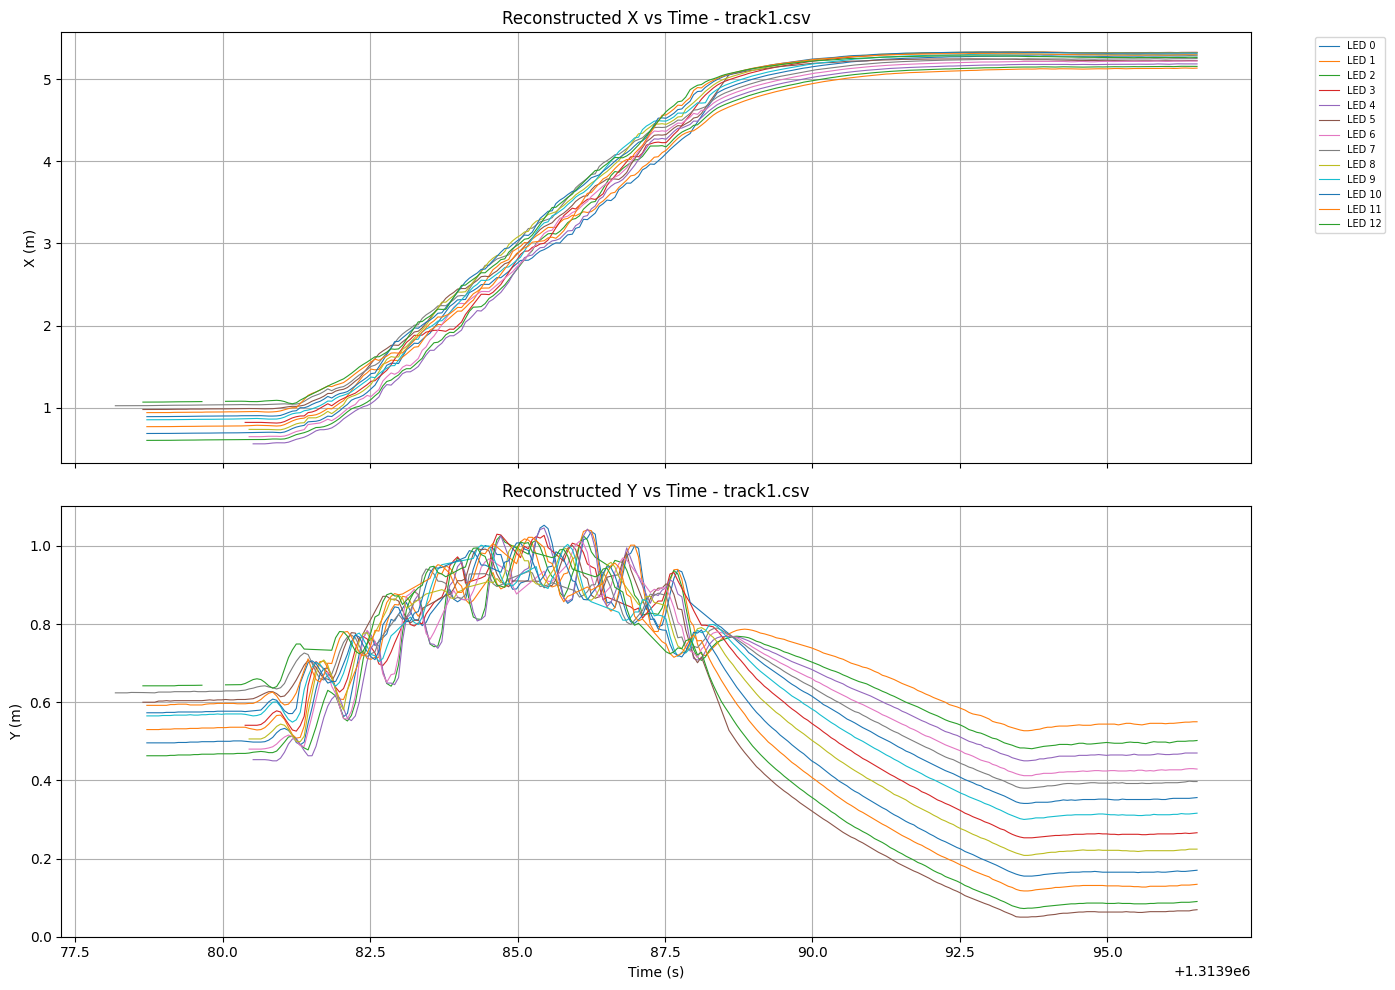

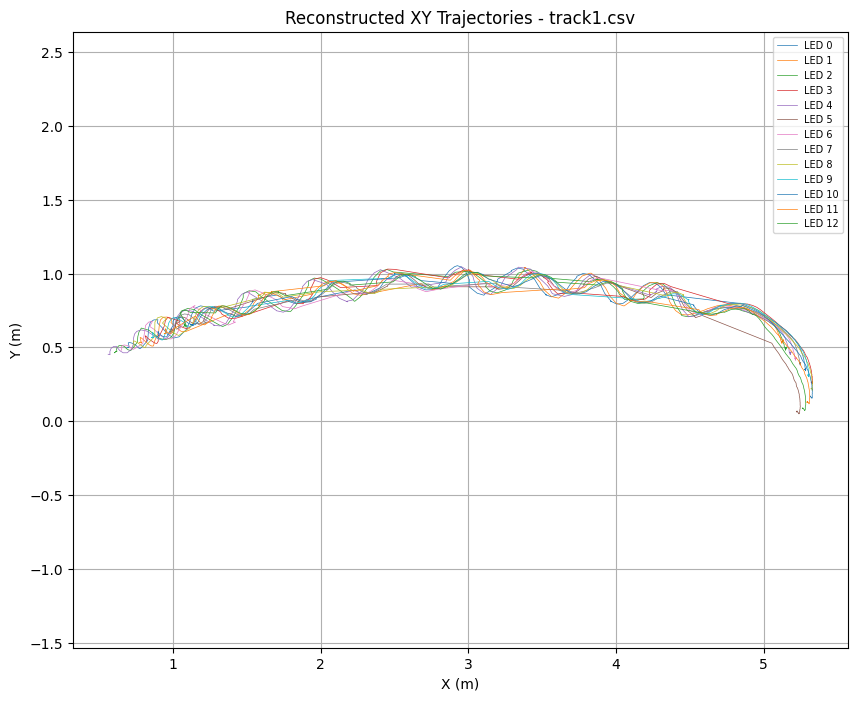

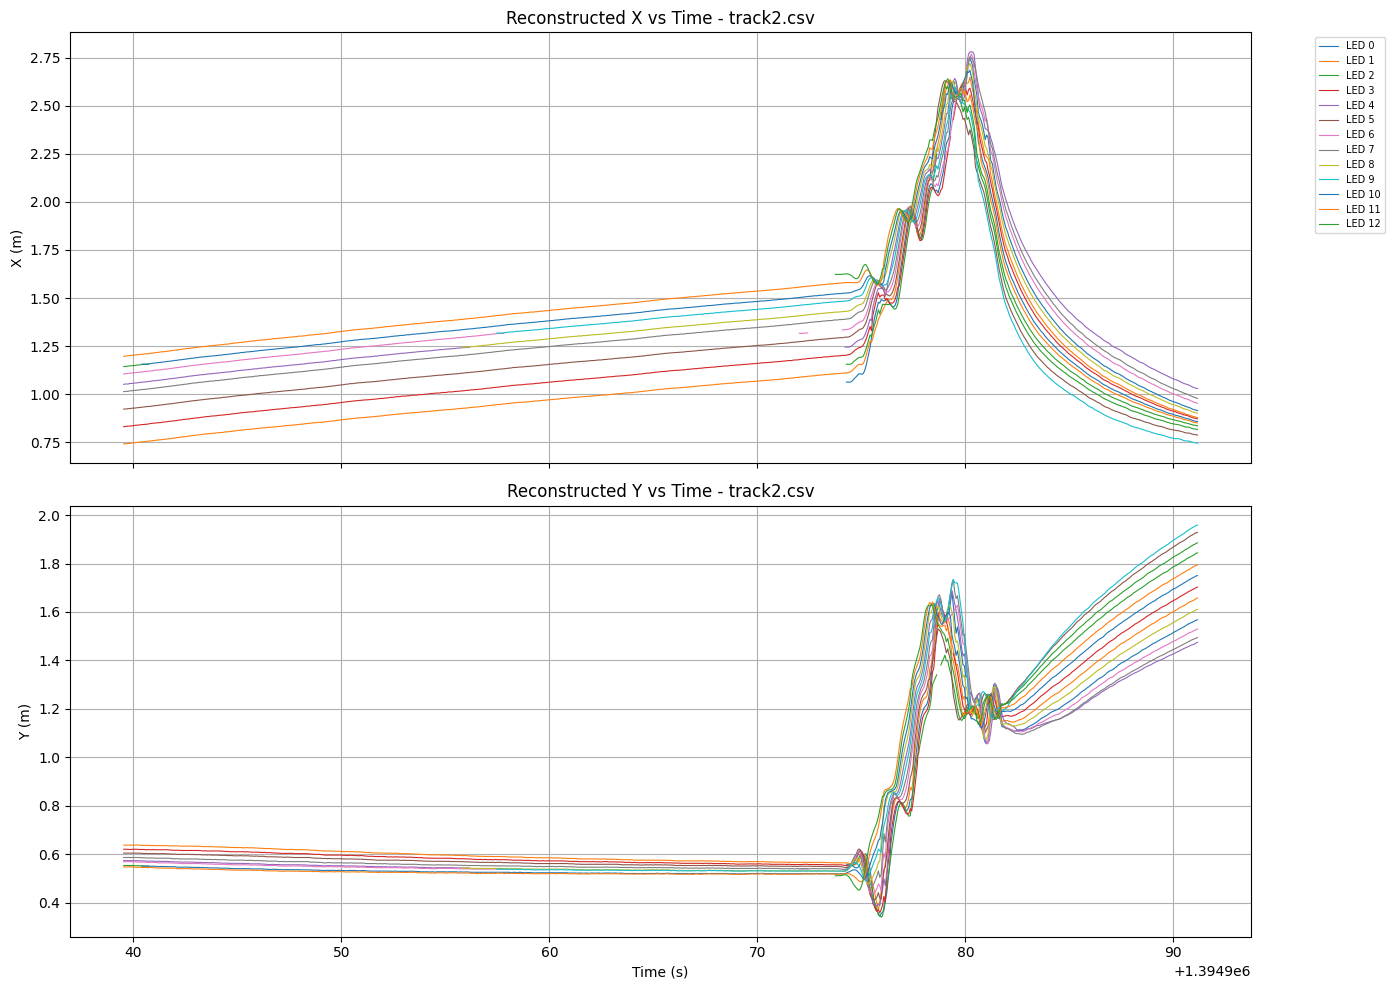

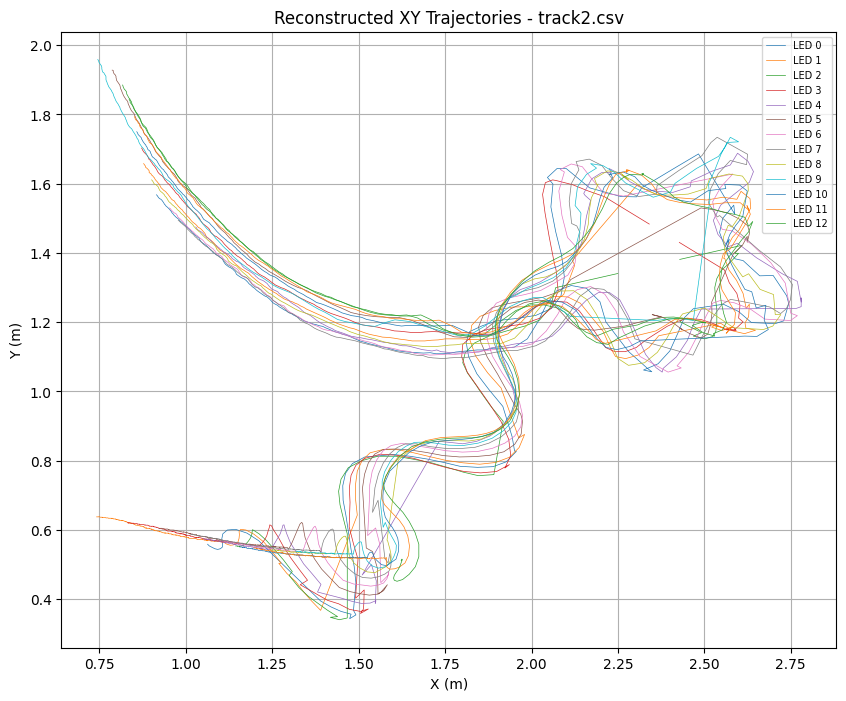

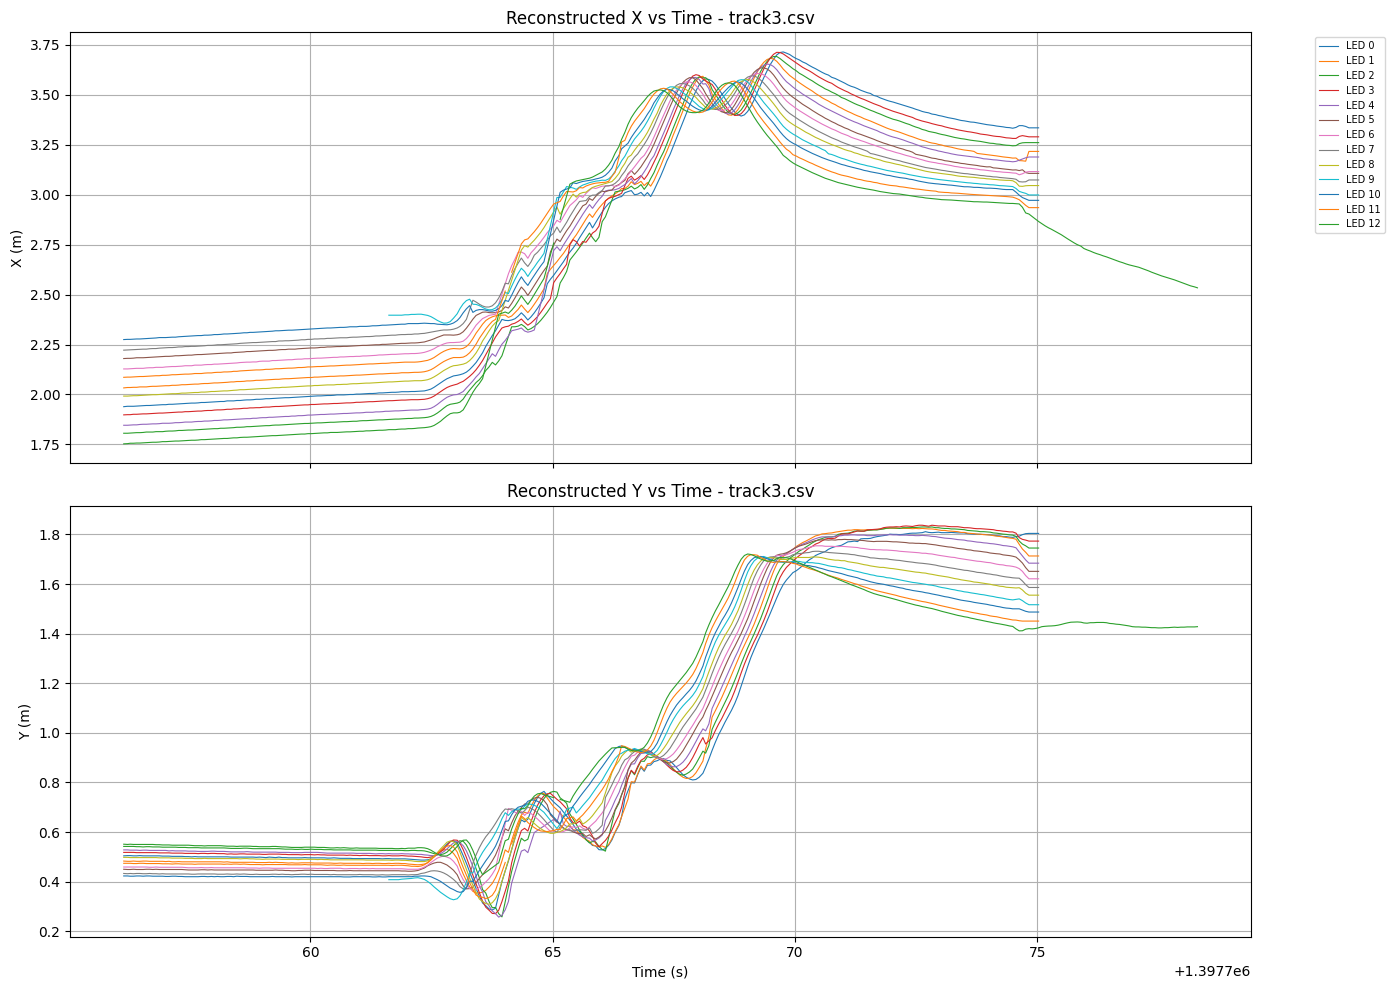

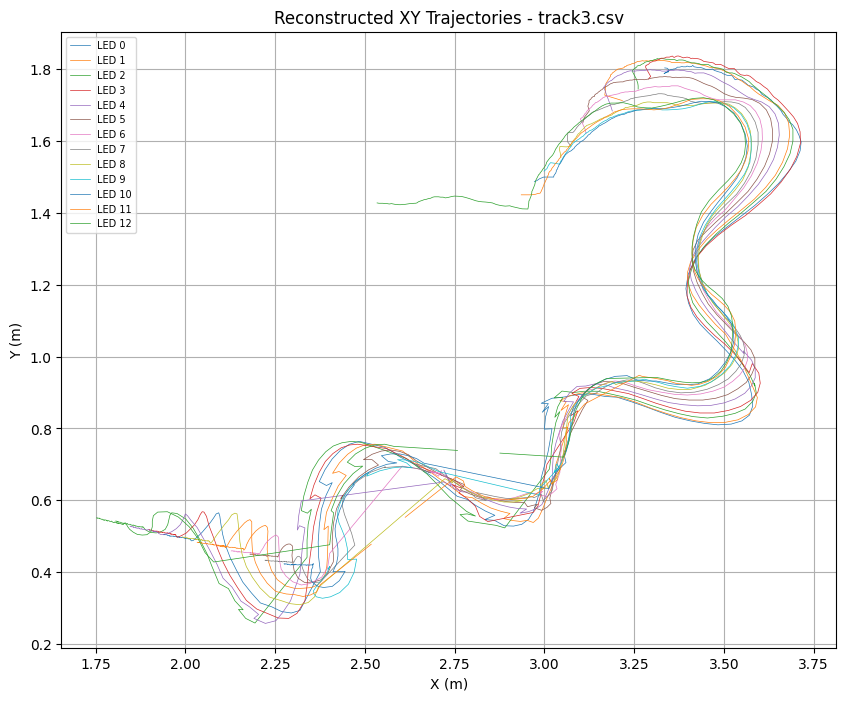

In [81]:
# Plot reconstructed tracks: X and Y vs time for each LED
for name, rdf in reconstructed_dfs.items():
    if rdf is None:
        continue

    x_cols = sorted([c for c in rdf.columns if c.startswith('led_') and c.endswith('_x')],
                    key=lambda c: int(c.split('_')[1]))
    n_tracks = len(x_cols)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    for t_idx in range(n_tracks):
        xc = f'led_{t_idx}_x'
        yc = f'led_{t_idx}_y'
        ax1.plot(rdf['time'], rdf[xc], '-', linewidth=0.8, label=f'LED {t_idx}')
        ax2.plot(rdf['time'], rdf[yc], '-', linewidth=0.8, label=f'LED {t_idx}')

    ax1.set_title(f'Reconstructed X vs Time - {name}')
    ax1.set_ylabel('X (m)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
    ax1.grid(True)

    ax2.set_title(f'Reconstructed Y vs Time - {name}')
    ax2.set_ylabel('Y (m)')
    ax2.set_xlabel('Time (s)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Also plot XY trajectories
    plt.figure(figsize=(10, 8))
    for t_idx in range(n_tracks):
        xc = f'led_{t_idx}_x'
        yc = f'led_{t_idx}_y'
        plt.plot(rdf[xc], rdf[yc], '-', linewidth=0.5, label=f'LED {t_idx}')

    plt.title(f'Reconstructed XY Trajectories - {name}')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.axis('equal')
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.show()

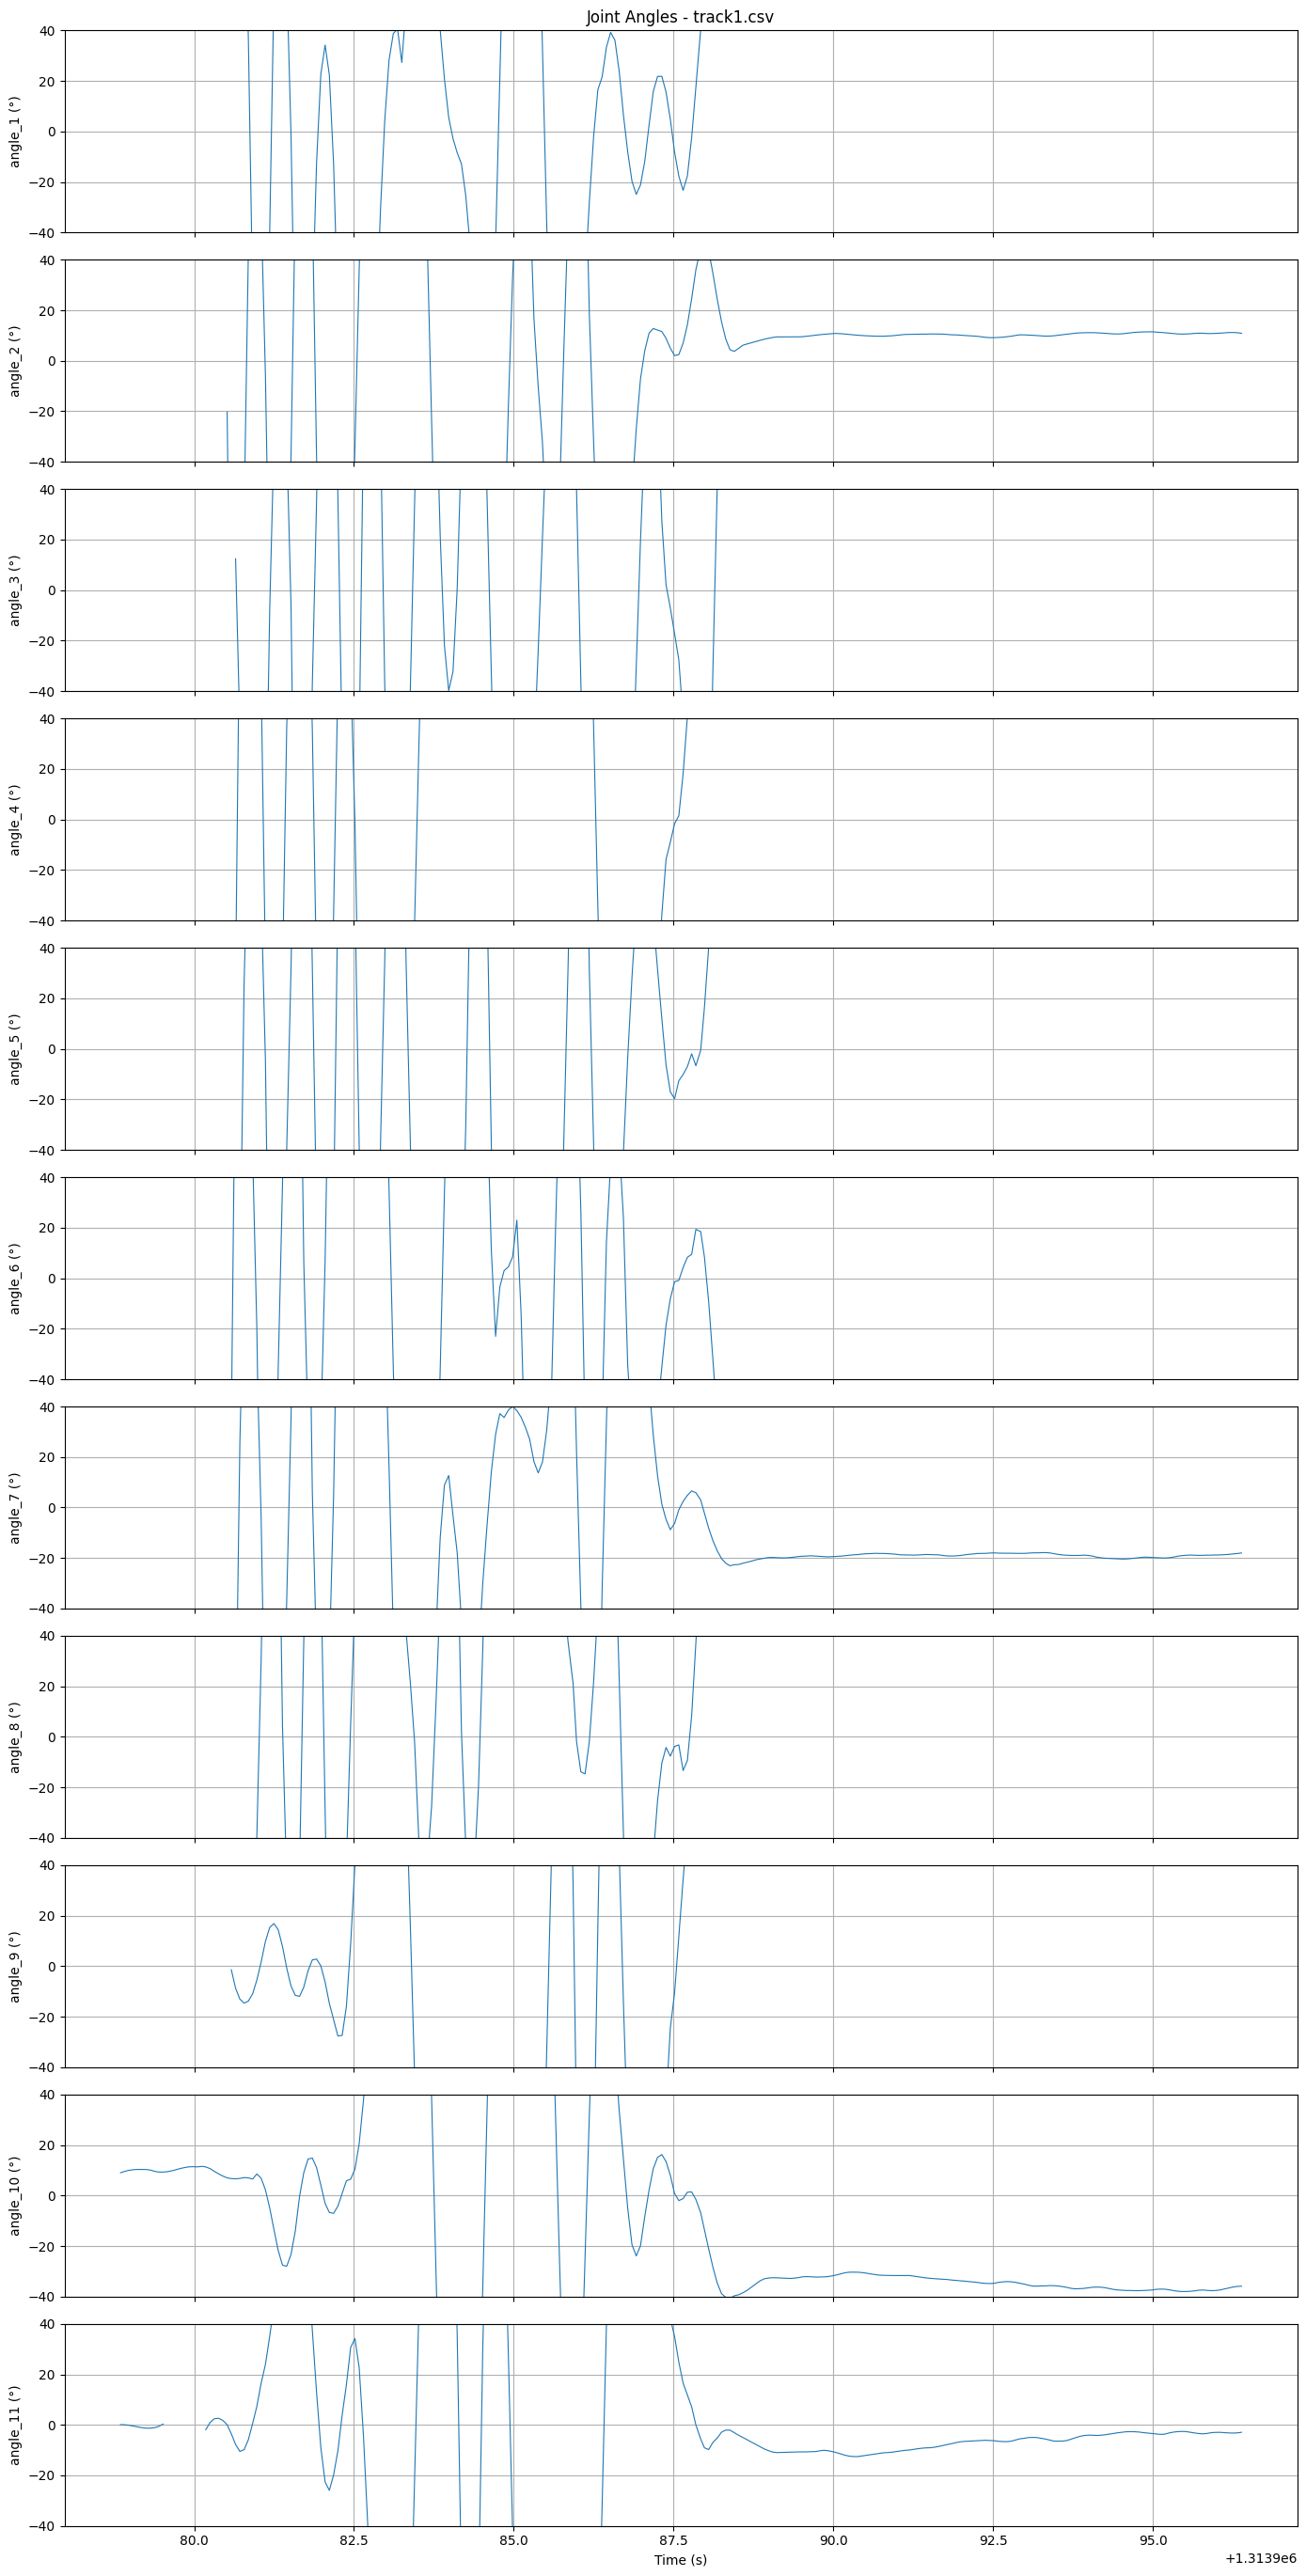

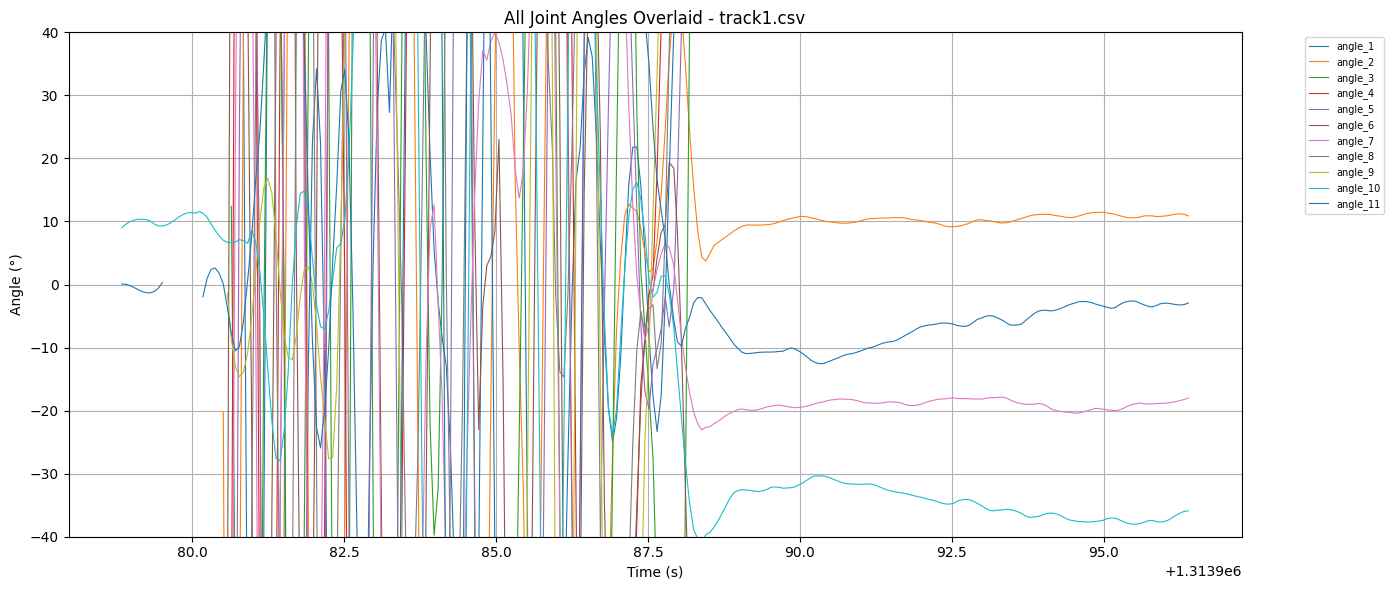

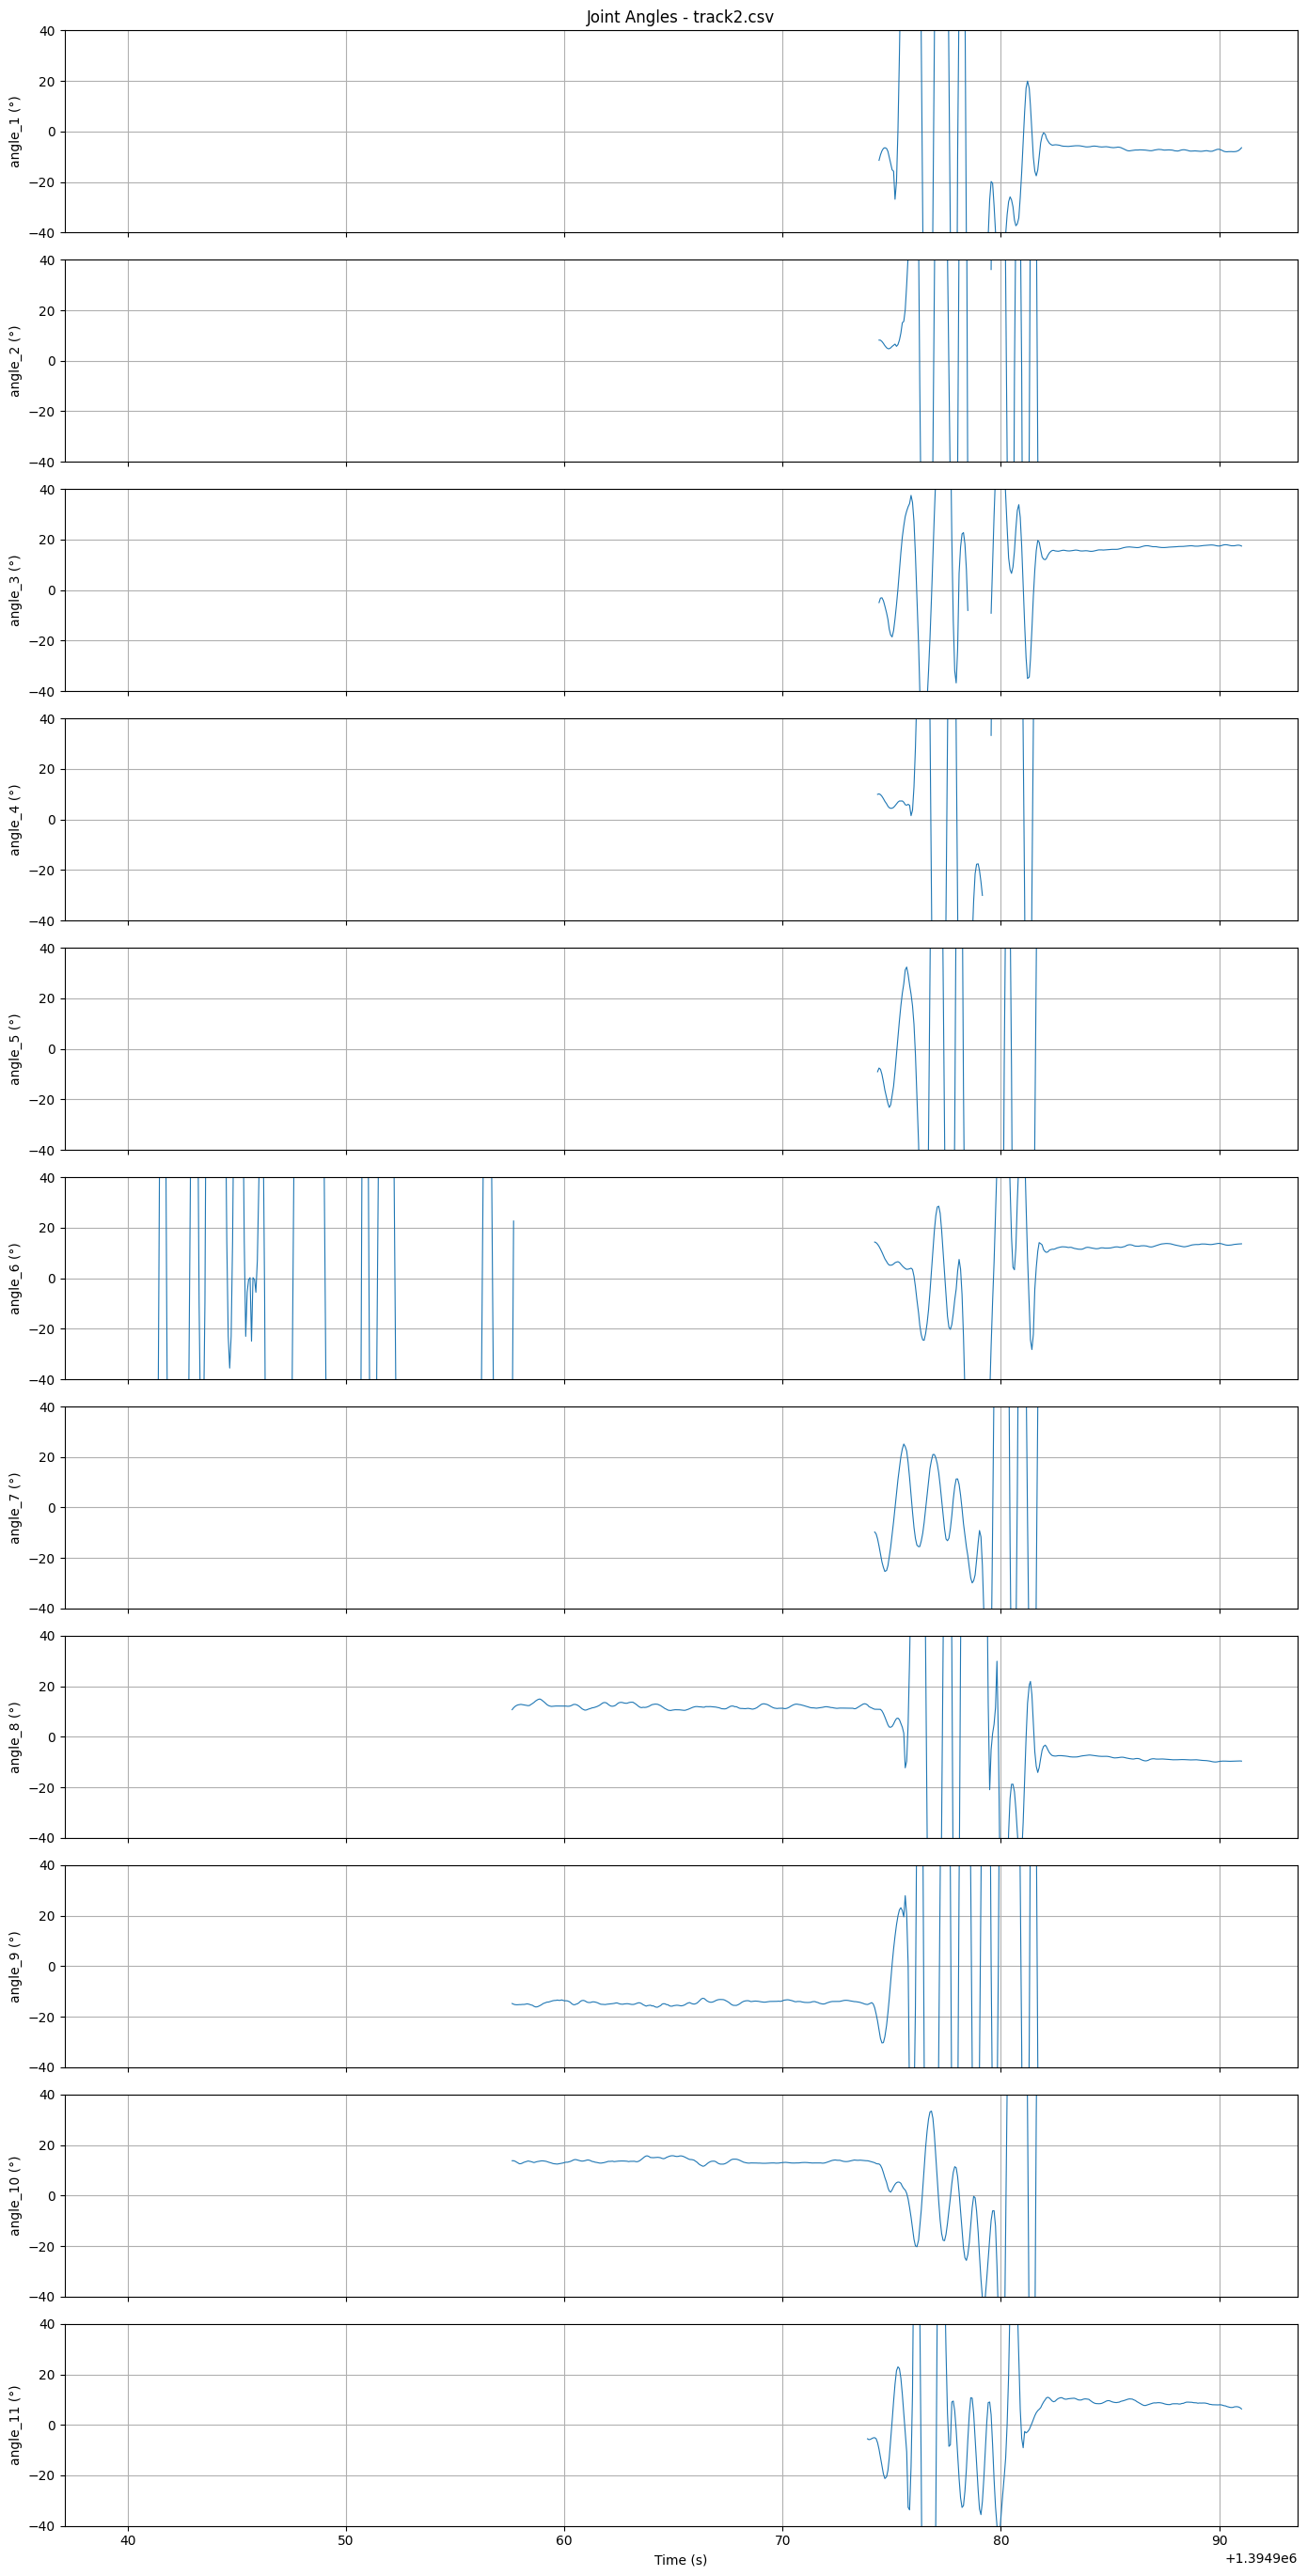

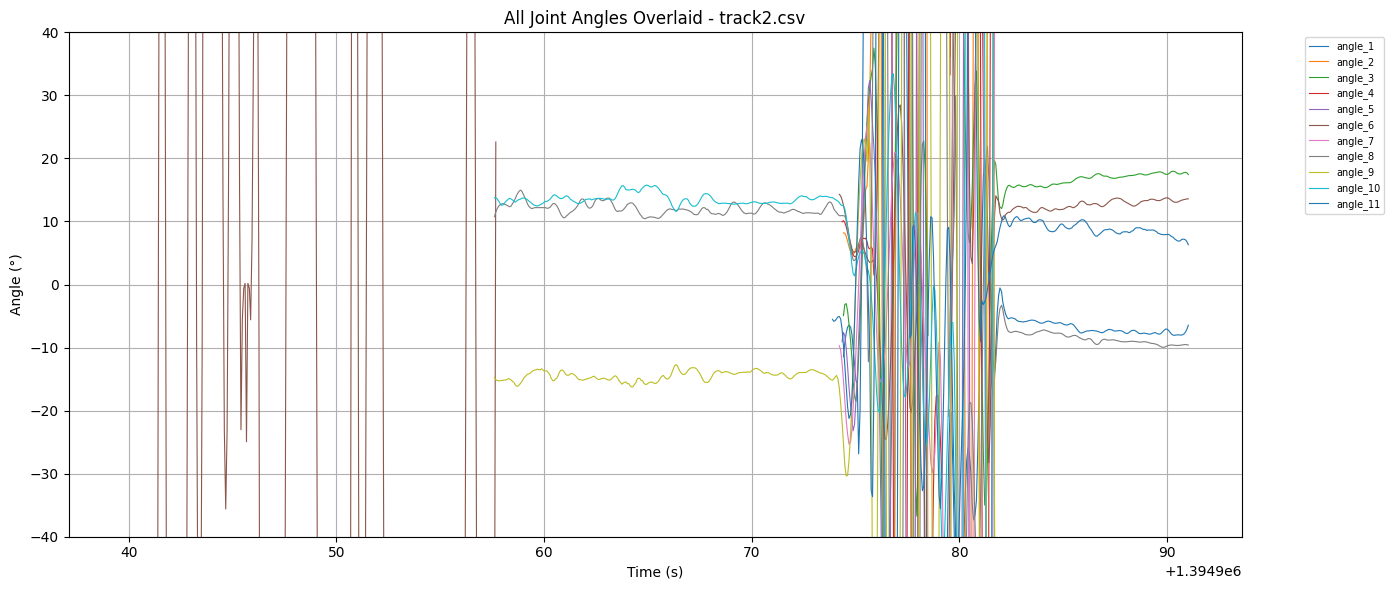

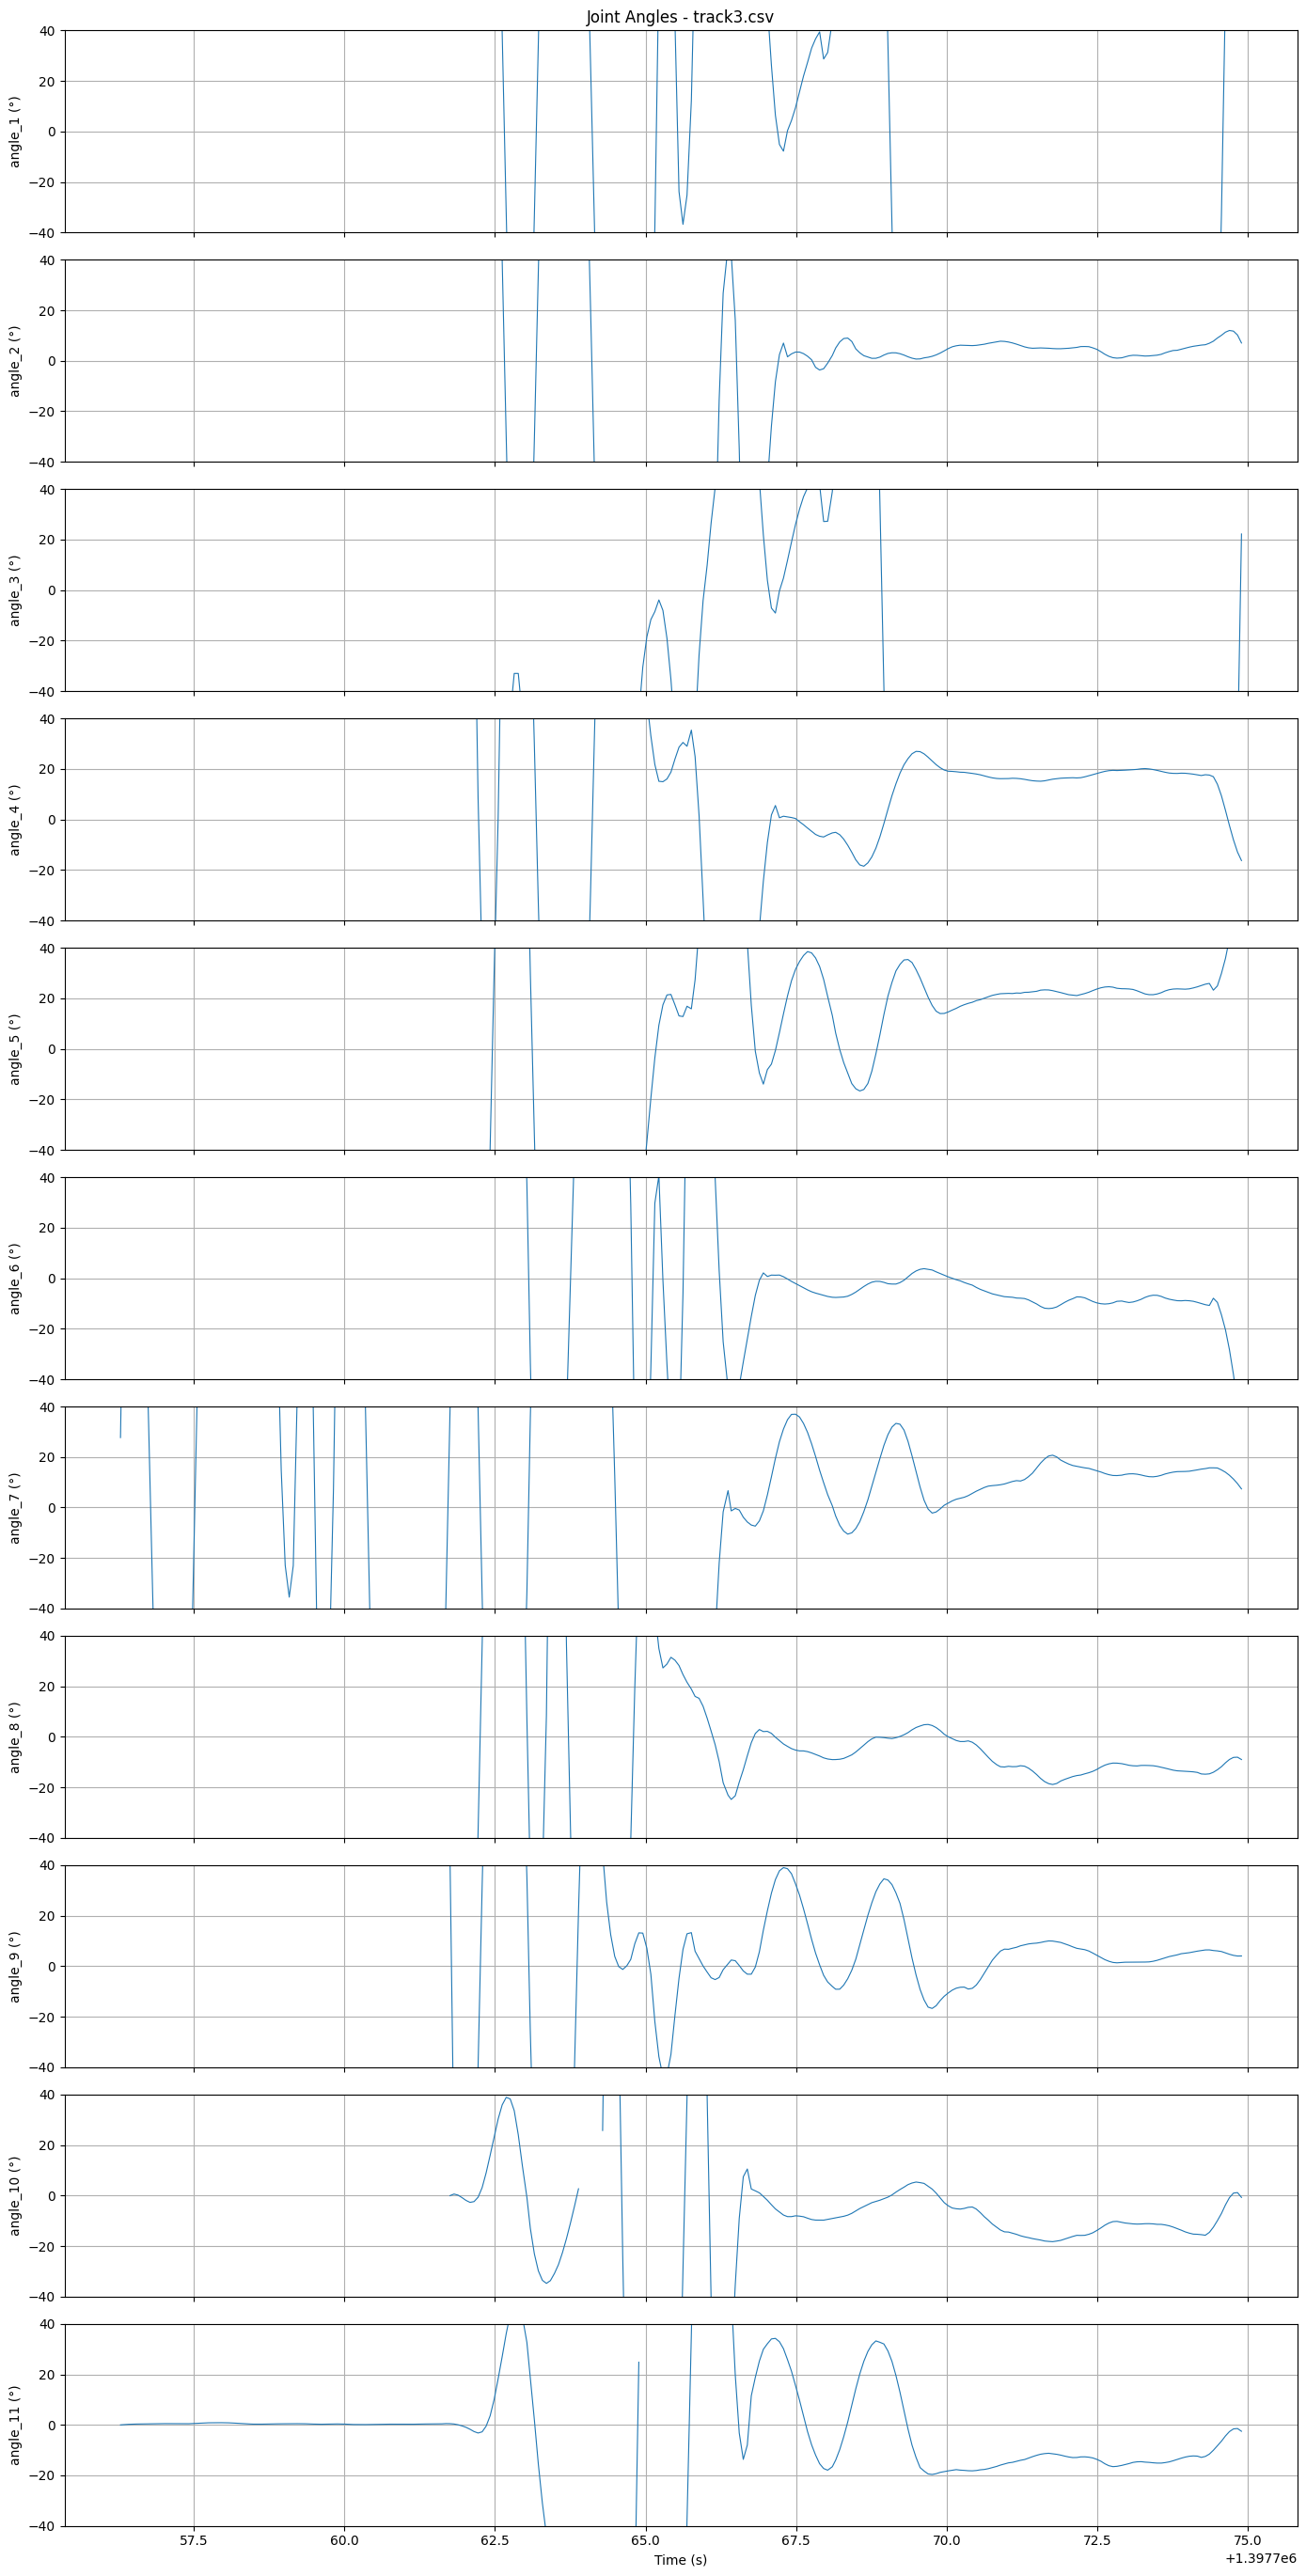

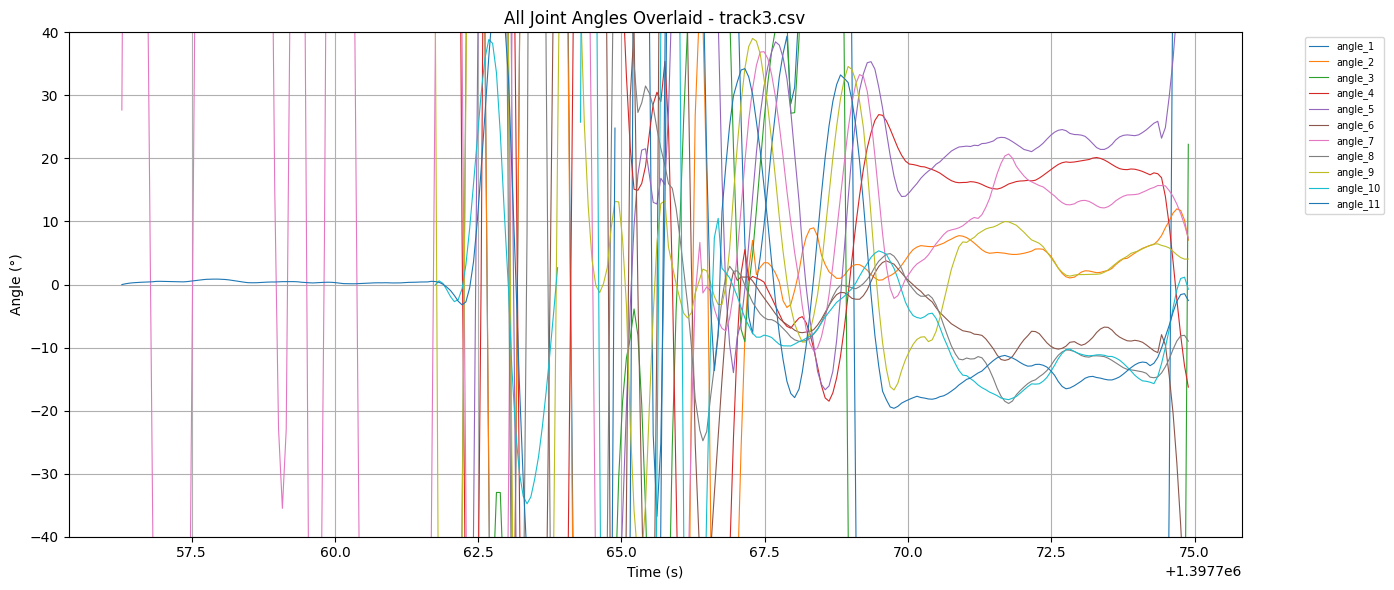

In [83]:
from scipy.signal import savgol_filter, medfilt

def find_contiguous_segments(mask):
    """Find start/end indices of contiguous True runs in a boolean array."""
    changes = np.diff(mask.astype(int))
    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1
    if mask[0]:
        starts = np.concatenate([[0], starts])
    if mask[-1]:
        ends = np.concatenate([ends, [len(mask)]])
    return list(zip(starts, ends))

def compute_joint_angles(rdf, n_tracks, min_segment=8, trim=2):
    """Compute deflection angles with robust segment-based cleaning.

    Pipeline per angle:
    1. Compute raw deflection angle (NaN propagates from position gaps)
    2. Find contiguous non-NaN segments
    3. Discard segments shorter than min_segment frames
    4. Trim `trim` frames from each segment boundary (camera handoff artifacts)
    5. Within each segment: median filter → Savitzky-Golay smoothing
    """
    angles = {'time': rdf['time'].values}

    for i in range(1, n_tracks - 1):
        # Vectors between consecutive LEDs
        v1x = rdf[f'led_{i}_x'].values - rdf[f'led_{i-1}_x'].values
        v1y = rdf[f'led_{i}_y'].values - rdf[f'led_{i-1}_y'].values
        v2x = rdf[f'led_{i+1}_x'].values - rdf[f'led_{i}_x'].values
        v2y = rdf[f'led_{i+1}_y'].values - rdf[f'led_{i}_y'].values

        # Signed deflection angle
        ang1 = np.arctan2(v1y, v1x)
        ang2 = np.arctan2(v2y, v2x)
        diff = ang2 - ang1
        diff = (diff + np.pi) % (2 * np.pi) - np.pi
        raw_deg = np.degrees(diff)

        # Find contiguous non-NaN segments
        not_nan = ~np.isnan(raw_deg)
        segments = find_contiguous_segments(not_nan)

        result = np.full_like(raw_deg, np.nan)

        for seg_start, seg_end in segments:
            seg_len = seg_end - seg_start

            # Discard very short segments (isolated garbage points)
            if seg_len < min_segment:
                continue

            # Trim boundaries to remove camera handoff artifacts
            s = seg_start + trim
            e = seg_end - trim
            if e - s < 5:
                # If too short after trimming, keep all but still require min length
                s, e = seg_start, seg_end
                if e - s < 5:
                    continue

            segment = raw_deg[s:e].copy()

            # Median filter to kill isolated spikes within the segment
            k = min(5, len(segment) if len(segment) % 2 == 1 else len(segment) - 1)
            if k >= 3:
                segment = medfilt(segment, kernel_size=k)

            # Savitzky-Golay smoothing
            sg_win = min(11, len(segment) if len(segment) % 2 == 1 else len(segment) - 1)
            if sg_win >= 5:
                segment = savgol_filter(segment, sg_win, min(3, sg_win - 1))

            result[s:e] = segment

        angles[f'angle_{i}'] = result

    return pd.DataFrame(angles)

# Compute and plot for each track
all_angles = {}
for name, rdf in reconstructed_dfs.items():
    if rdf is None:
        continue

    x_cols = [c for c in rdf.columns if c.startswith('led_') and c.endswith('_x')]
    n_tracks = len(x_cols)

    angles_df = compute_joint_angles(rdf, n_tracks)
    all_angles[name] = angles_df

    angle_cols = [c for c in angles_df.columns if c.startswith('angle_')]
    n_angles = len(angle_cols)

    # Plot all angles on individual subplots
    fig, axes = plt.subplots(n_angles, 1, figsize=(14, 2.5 * n_angles), sharex=True)
    if n_angles == 1:
        axes = [axes]

    for idx, col in enumerate(angle_cols):
        axes[idx].plot(angles_df['time'], angles_df[col], '-', linewidth=0.8)
        axes[idx].set_ylabel(f'{col} (°)')
        axes[idx].grid(True)
        axes[idx].set_ylim(-40, 40)

    axes[0].set_title(f'Joint Angles - {name}')
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

    # Plot all angles overlaid
    plt.figure(figsize=(14, 6))
    for col in angle_cols:
        plt.plot(angles_df['time'], angles_df[col], '-', linewidth=0.8, label=col)
    plt.title(f'All Joint Angles Overlaid - {name}')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (°)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
    plt.grid(True)
    plt.ylim(-40, 40)
    plt.tight_layout()
    plt.show()